# Space Invaders PPO CNN v1

Proximal Policy Optimization (PPO) implementation for Atari Space Invaders, adapted from our Pong PPO implementation.

## Key Adaptations from Pong PPO

### Environment Differences

- **Action space**: Space Invaders has 6 actions (NOOP, FIRE, RIGHT, LEFT, RIGHTFIRE, LEFTFIRE)
- **Reward structure**: Points for destroying aliens (10-30 pts each), mystery ship (50-200 pts). Rewards are clipped to [-1, 1] for stable training
- **Episode termination**: Losing all 3 lives ends the episode. Scores typically range 0-1000+ for trained agents
- **Target reward**: 500 mean reward over 100 episodes

### Architecture

- **CNN filters**: 32-64-64 (larger than Pong's 32-36-20) to handle more complex visual patterns
- **Reward clipping**: Clips rewards to [-1, 1] for training stability (tracks raw rewards for evaluation)

### PPO Recap

PPO collects large batches of experience, then performs multiple epochs of updates with a clipped surrogate objective:

```
ratio = pi_new(a|s) / pi_old(a|s)
L = -min(ratio * A, clip(ratio, 1-eps, 1+eps) * A)
```

This prevents destructively large policy updates while reusing data efficiently.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output
from collections import deque
import cv2
import mlflow
import mlflow.pytorch
import wandb
import os
from dotenv import load_dotenv
from pathlib import Path

# Import logging utilities
from logging_utils import (
    log_hyperparameters,
    log_model_info,
    log_episode_metrics,
    log_a2c_losses,
    save_checkpoint,
    save_training_plot,
    display_training_plot,
    log_final_results,
    setup_weight_tracking,
    log_layer_wise_gradient_norms,
    log_weight_stats
)

import ale_py
gym.register_envs(ale_py)

## Reproducibility

In [2]:
SEED = 24127

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Random seed set to: {SEED}")

Random seed set to: 24127


/home/bmartins/anaconda3/envs/rl_study_312/lib/python3.12/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Preprocessing Functions

In [3]:
def preprocess_frame(frame):
    """Convert frame to grayscale, crop, resize to 84x84, and normalize."""
    gray = np.mean(frame, axis=2).astype(np.uint8)
    cropped = gray[34:194, :]
    resized = cv2.resize(cropped, (84, 84), interpolation=cv2.INTER_AREA)
    return resized.astype(np.float32) / 255.0


class FrameStack:
    """Stack multiple consecutive frames to capture temporal information."""
    def __init__(self, num_frames=2):
        self.num_frames = num_frames
        self.frames = deque(maxlen=num_frames)

    def reset(self, frame):
        processed_frame = preprocess_frame(frame)
        for _ in range(self.num_frames):
            self.frames.append(processed_frame)
        return self.get_stacked()

    def step(self, frame):
        processed_frame = preprocess_frame(frame)
        self.frames.append(processed_frame)
        return self.get_stacked()

    def get_stacked(self):
        return np.stack(list(self.frames), axis=0)

## PPO Network

Shared CNN features with separate actor and critic heads. Uses 32-64-64 filters (matching the Space Invaders A2C architecture).

In [4]:
class PPOAgent(nn.Module):
    """PPO Agent with shared CNN features, actor head, and critic head."""
    
    def __init__(self, input_channels, action_size):
        super(PPOAgent, self).__init__()
        
        # Shared CNN feature extractor (32->64->64 filters)
        self.conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=8, stride=4, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )
        
        # Calculate feature size
        self.feature_size = self._get_conv_output_size(input_channels)
        
        # Actor head (policy)
        self.actor_fc = nn.Linear(self.feature_size, 512)
        self.policy_head = nn.Linear(512, action_size)
        
        # Critic head (value)
        self.critic_fc = nn.Linear(self.feature_size, 512)
        self.value_head = nn.Linear(512, 1)
        
        self.action_size = action_size
    
    def _get_conv_output_size(self, input_channels):
        """Calculate the output size of conv layers."""
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, 84, 84)
            conv_output = self.conv(dummy_input)
            return conv_output.numel() // conv_output.size(0)
    
    def forward(self, state):
        """Forward pass: returns policy logits and value estimate."""
        # Shared CNN features
        features = self.conv(state)
        features = features.view(features.size(0), -1)
        
        # Actor: policy logits
        actor_hidden = F.relu(self.actor_fc(features))
        logits = self.policy_head(actor_hidden)
        
        # Critic: value estimate
        critic_hidden = F.relu(self.critic_fc(features))
        value = self.value_head(critic_hidden).squeeze(-1)
        
        return logits, value
    
    def get_action(self, state):
        """Sample action from policy and return action, log_prob, value."""
        logits, value = self.forward(state)
        probs = F.softmax(logits, dim=-1)
        
        # Sample action from categorical distribution
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        
        # Get log probability
        log_prob = dist.log_prob(action)
        
        return action, log_prob, value
    
    def evaluate_actions(self, states, actions):
        """Evaluate actions for PPO update: returns log_probs, values, entropy."""
        logits, values = self.forward(states)
        probs = F.softmax(logits, dim=-1)
        
        dist = torch.distributions.Categorical(probs)
        log_probs = dist.log_prob(actions)
        entropy = dist.entropy()
        
        return log_probs, values, entropy

## Rollout Buffer

Stores experience for PPO training. Unlike A2C which updates after a few steps, PPO collects a large batch before updating.

In [5]:
class RolloutBuffer:
    """Buffer to store rollout experience for PPO."""
    
    def __init__(self):
        self.states = []
        self.actions = []
        self.rewards = []
        self.dones = []
        self.values = []
        self.log_probs = []
        
        # Computed after rollout
        self.advantages = None
        self.returns = None
    
    def add(self, state, action, reward, done, value, log_prob):
        """Add a transition to the buffer."""
        self.states.append(state)
        self.actions.append(action)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)
        self.log_probs.append(log_prob)
    
    def compute_gae(self, last_value, gamma, gae_lambda):
        """Compute Generalized Advantage Estimation."""
        rewards = np.array(self.rewards)
        dones = np.array(self.dones)
        values = np.array(self.values + [last_value])
        
        # GAE computation (working backwards)
        advantages = np.zeros_like(rewards)
        gae = 0
        
        for t in reversed(range(len(rewards))):
            # TD error: delta = r + gamma * V(s') - V(s)
            delta = rewards[t] + gamma * values[t + 1] * (1 - dones[t]) - values[t]
            # GAE: A = delta + gamma * lambda * A'
            gae = delta + gamma * gae_lambda * (1 - dones[t]) * gae
            advantages[t] = gae
        
        # Returns = advantages + values
        returns = advantages + np.array(self.values)
        
        self.advantages = advantages
        self.returns = returns
    
    def get_batches(self, batch_size, device):
        """Generate minibatches for training."""
        n_samples = len(self.states)
        indices = np.random.permutation(n_samples)
        
        # Convert to tensors
        states = torch.FloatTensor(np.array(self.states)).to(device)
        actions = torch.LongTensor(self.actions).to(device)
        old_log_probs = torch.FloatTensor(self.log_probs).to(device)
        advantages = torch.FloatTensor(self.advantages).to(device)
        returns = torch.FloatTensor(self.returns).to(device)
        
        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        # Generate minibatches
        for start in range(0, n_samples, batch_size):
            end = start + batch_size
            batch_indices = indices[start:end]
            
            yield (
                states[batch_indices],
                actions[batch_indices],
                old_log_probs[batch_indices],
                advantages[batch_indices],
                returns[batch_indices]
            )
    
    def clear(self):
        """Clear the buffer."""
        self.states = []
        self.actions = []
        self.rewards = []
        self.dones = []
        self.values = []
        self.log_probs = []
        self.advantages = None
        self.returns = None
    
    def __len__(self):
        return len(self.states)

## PPO Loss Functions

In [6]:
def compute_ppo_loss(agent, states, actions, old_log_probs, advantages, returns,
                     clip_epsilon, value_loss_coef, entropy_coef):
    """
    Compute PPO loss with clipped surrogate objective.
    
    Returns:
        total_loss: Combined loss for backprop
        policy_loss: Clipped surrogate loss
        value_loss: MSE loss for value function
        entropy_loss: Negative entropy (for loss minimization)
    """
    # Get current policy evaluation
    new_log_probs, values, entropy = agent.evaluate_actions(states, actions)
    
    # Policy loss with clipping
    ratio = torch.exp(new_log_probs - old_log_probs)
    
    # Unclipped objective
    surr1 = ratio * advantages
    
    # Clipped objective
    surr2 = torch.clamp(ratio, 1.0 - clip_epsilon, 1.0 + clip_epsilon) * advantages
    
    # Take the minimum (pessimistic bound)
    policy_loss = -torch.min(surr1, surr2).mean()
    
    # Value loss (MSE)
    value_loss = F.mse_loss(values, returns)
    
    # Entropy loss (negative because we want to maximize entropy)
    entropy_loss = -entropy.mean()
    
    # Total loss
    total_loss = policy_loss + value_loss_coef * value_loss + entropy_coef * entropy_loss
    
    return total_loss, policy_loss, value_loss, entropy_loss, ratio

## Hyperparameters and Setup

In [ ]:
# PPO Hyperparameters
LEARNING_RATE = 2.5e-4
GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_EPSILON = 0.2
VALUE_LOSS_COEF = 0.5
ENTROPY_COEF = 0.01
MAX_GRAD_NORM = 0.5

# PPO-specific parameters
ROLLOUT_LENGTH = 128        # Steps to collect before update
PPO_EPOCHS = 4              # Number of epochs per update
MINIBATCH_SIZE = 32         # Minibatch size for SGD

# Training parameters
MEAN_REWARD_BOUND = 500     # Space Invaders target

# Environment parameters
FRAME_SKIP = 4
INPUT_CHANNELS = 2

# Logging
LOG_FREQ = 100
CHECKPOINT_FREQ = 500
GRADIENT_LOG_FREQ = 100

# Architecture
ARCHITECTURE_NAME = "CNN-PPO-SpaceInvaders"
MODEL_FILTERS = "32-64-64"

# Hyperparameters dict
HYPERPARAMETERS = {
    "algorithm": "PPO",
    "game": "SpaceInvaders",
    "seed": SEED,
    "learning_rate": LEARNING_RATE,
    "gamma": GAMMA,
    "gae_lambda": GAE_LAMBDA,
    "clip_epsilon": CLIP_EPSILON,
    "value_loss_coef": VALUE_LOSS_COEF,
    "entropy_coef": ENTROPY_COEF,
    "max_grad_norm": MAX_GRAD_NORM,
    "rollout_length": ROLLOUT_LENGTH,
    "ppo_epochs": PPO_EPOCHS,
    "minibatch_size": MINIBATCH_SIZE,
    "mean_reward_bound": MEAN_REWARD_BOUND,
    "frame_skip": FRAME_SKIP,
    "input_channels": INPUT_CHANNELS,
    "architecture": ARCHITECTURE_NAME,
    "model_filters": MODEL_FILTERS,
    "reward_clipping": True,
}

# Setup directories
RL_STUDY_DIR = Path.cwd().parent.parent if Path.cwd().name == 'space_invaders_ppo_cnn' else Path.cwd()
MLFLOW_TRACKING_URI = RL_STUDY_DIR / 'mlruns'
WANDB_DIR = RL_STUDY_DIR / 'wandb'
BASE_ARTIFACTS_DIR = RL_STUDY_DIR / 'artifacts'

# Create directories
WANDB_DIR.mkdir(exist_ok=True)
BASE_ARTIFACTS_DIR.mkdir(exist_ok=True)
MLFLOW_TRACKING_URI.mkdir(exist_ok=True)

# Configure MLflow
mlflow.set_tracking_uri(f'file://{MLFLOW_TRACKING_URI}')

# Configure wandb
os.environ['WANDB_DIR'] = str(WANDB_DIR)
load_dotenv(RL_STUDY_DIR / '.env')
wandb_key = os.getenv('WANDB_KEY')
wandb.login(key=wandb_key)

wandb.init(
    project="space_invaders_ppo_training",
    name="space_invaders_cnn_ppo_v1",
    dir=str(WANDB_DIR),
    config=HYPERPARAMETERS
)

print(f"Setup complete!")
print(f"Random seed: {SEED}")
print(f"Rollout: {ROLLOUT_LENGTH} steps, PPO epochs: {PPO_EPOCHS}, Minibatch: {MINIBATCH_SIZE}")
print(f"Clip epsilon: {CLIP_EPSILON}, GAE lambda: {GAE_LAMBDA}, LR: {LEARNING_RATE}")
print(f"Reward clipping: Enabled, Target: {MEAN_REWARD_BOUND}")

## PPO Training Function

In [ ]:
def train_ppo():
    # End any active runs
    if mlflow.active_run():
        mlflow.end_run()
    
    # MLflow experiment setup
    mlflow.set_experiment("space_invaders_ppo_training")
    
    with mlflow.start_run():
        # Create artifacts directory
        run_id = mlflow.active_run().info.run_id
        artifacts_dir = BASE_ARTIFACTS_DIR / f"run_{run_id}"
        artifacts_dir.mkdir(parents=True, exist_ok=True)
        print(f"Artifacts will be saved to: {artifacts_dir}")
        
        # Log hyperparameters
        log_hyperparameters(HYPERPARAMETERS)
        
        # Environment setup
        env = gym.make('SpaceInvadersNoFrameskip-v4')
        env.reset(seed=SEED)
        action_size = env.action_space.n
        
        # Device
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {device}")
        
        # Create agent
        agent = PPOAgent(input_channels=INPUT_CHANNELS, action_size=action_size).to(device)
        optimizer = optim.Adam(agent.parameters(), lr=LEARNING_RATE, eps=1e-5)
        
        # Setup weight tracking
        setup_weight_tracking(agent, log_freq=GRADIENT_LOG_FREQ, log_all=True)
        
        # Log model info
        total_params = log_model_info(agent)
        print(f"Total parameters: {total_params:,}")
        
        # Training state
        rollout_buffer = RolloutBuffer()
        episode_rewards = []     # Raw (unclipped) rewards for evaluation
        episode = 0
        total_timesteps = 0
        total_updates = 0
        
        # Current episode tracking
        state, _ = env.reset()
        frame_stack = FrameStack(INPUT_CHANNELS)
        stacked_state = frame_stack.reset(state)
        current_episode_reward_raw = 0    # Unclipped for tracking
        current_episode_length = 0
        
        print("Starting PPO training on Space Invaders (no step limit)...\n")
        
        while True:
            # Collect rollout
            rollout_buffer.clear()
            
            for _ in range(ROLLOUT_LENGTH):
                # Get action from policy
                state_tensor = torch.FloatTensor(stacked_state).unsqueeze(0).to(device)
                
                with torch.no_grad():
                    action, log_prob, value = agent.get_action(state_tensor)
                
                # Execute action with frame skip
                step_reward = 0
                terminated = False
                truncated = False
                
                for _ in range(FRAME_SKIP):
                    next_frame, reward, terminated, truncated, _ = env.step(action.item())
                    step_reward += reward
                    if terminated or truncated:
                        break
                
                done = terminated or truncated
                
                # Clip reward for training stability
                step_reward_clipped = np.clip(step_reward, -1.0, 1.0)
                
                # Store transition with clipped reward
                rollout_buffer.add(
                    state=stacked_state,
                    action=action.item(),
                    reward=step_reward_clipped,
                    done=done,
                    value=value.item(),
                    log_prob=log_prob.item()
                )
                
                current_episode_reward_raw += step_reward
                current_episode_length += 1
                total_timesteps += 1
                
                # Update state
                stacked_state = frame_stack.step(next_frame)
                
                # Handle episode end
                if done:
                    episode_rewards.append(current_episode_reward_raw)
                    mean_reward = np.mean(episode_rewards[-100:]) if len(episode_rewards) >= 100 else np.mean(episode_rewards)
                    
                    # Log episode metrics
                    log_episode_metrics(current_episode_reward_raw, mean_reward, 
                                       current_episode_length, episode, total_updates)
                    
                    # Print progress
                    if episode % 10 == 0:
                        avg_reward = np.mean(episode_rewards[-10:]) if len(episode_rewards) >= 10 else np.mean(episode_rewards)
                        max_reward = max(episode_rewards) if episode_rewards else 0
                        print(f"Episode {episode:4d} | Reward: {current_episode_reward_raw:6.1f} | "
                              f"Avg(10): {avg_reward:6.2f} | Mean(100): {mean_reward:6.2f} | "
                              f"Max: {max_reward:6.1f} | Steps: {total_timesteps:,}")
                    
                    # Check stopping condition
                    if mean_reward >= MEAN_REWARD_BOUND:
                        print(f"\nEnvironment solved in {episode} episodes!")
                        print(f"Mean reward: {mean_reward:.2f} >= {MEAN_REWARD_BOUND}")
                        wandb.log({"solved_at_episode": episode}, step=total_updates)
                        
                        # Save final results and return
                        final_model_path = log_final_results(agent, episode, mean_reward, 
                                                            episode_rewards, artifacts_dir, run_id)
                        env.close()
                        wandb.finish()
                        return agent, episode_rewards
                    
                    # Reset for new episode
                    state, _ = env.reset()
                    stacked_state = frame_stack.reset(state)
                    current_episode_reward_raw = 0
                    current_episode_length = 0
                    episode += 1
            
            # Compute GAE and returns
            with torch.no_grad():
                last_state_tensor = torch.FloatTensor(stacked_state).unsqueeze(0).to(device)
                _, last_value = agent.forward(last_state_tensor)
                last_value = last_value.item()
            
            rollout_buffer.compute_gae(last_value, GAMMA, GAE_LAMBDA)
            
            # PPO update
            epoch_policy_losses = []
            epoch_value_losses = []
            epoch_entropy_losses = []
            epoch_total_losses = []
            epoch_clip_fractions = []
            
            for epoch in range(PPO_EPOCHS):
                for batch in rollout_buffer.get_batches(MINIBATCH_SIZE, device):
                    states, actions, old_log_probs, advantages, returns = batch
                    
                    # Compute PPO loss
                    total_loss, policy_loss, value_loss, entropy_loss, ratio = compute_ppo_loss(
                        agent, states, actions, old_log_probs, advantages, returns,
                        CLIP_EPSILON, VALUE_LOSS_COEF, ENTROPY_COEF
                    )
                    
                    # Backpropagation
                    optimizer.zero_grad()
                    total_loss.backward()
                    torch.nn.utils.clip_grad_norm_(agent.parameters(), MAX_GRAD_NORM)
                    optimizer.step()
                    
                    # Track metrics
                    epoch_policy_losses.append(policy_loss.item())
                    epoch_value_losses.append(value_loss.item())
                    epoch_entropy_losses.append(entropy_loss.item())
                    epoch_total_losses.append(total_loss.item())
                    
                    # Clip fraction (how often clipping was active)
                    clip_fraction = torch.mean((torch.abs(ratio - 1.0) > CLIP_EPSILON).float()).item()
                    epoch_clip_fractions.append(clip_fraction)
                    
                    total_updates += 1
            
            # Log losses
            avg_policy_loss = np.mean(epoch_policy_losses)
            avg_value_loss = np.mean(epoch_value_losses)
            avg_entropy_loss = np.mean(epoch_entropy_losses)
            avg_total_loss = np.mean(epoch_total_losses)
            avg_clip_fraction = np.mean(epoch_clip_fractions)
            
            log_a2c_losses(avg_policy_loss, avg_value_loss, avg_entropy_loss, 
                          avg_total_loss, episode, total_updates)
            
            # Log PPO-specific metrics
            wandb.log({
                "ppo/clip_fraction": avg_clip_fraction,
                "ppo/approx_kl": 0.5 * np.mean([(r - 1) ** 2 for r in epoch_clip_fractions]),
                "system/total_timesteps": total_timesteps,
            }, step=total_updates)
            
            # Log gradients periodically
            if total_updates % GRADIENT_LOG_FREQ == 0:
                log_layer_wise_gradient_norms(agent, total_updates)
            
            # Plot every 100 episodes
            if episode % 100 == 0 and episode > 0 and len(episode_rewards) > 0:
                display_training_plot(episode_rewards, MEAN_REWARD_BOUND)
            
            # Save checkpoint
            if episode % CHECKPOINT_FREQ == 0 and episode > 0:
                save_checkpoint(artifacts_dir, episode, agent, optimizer, 
                               episode_rewards, run_id, total_updates)
                save_training_plot(artifacts_dir, episode_rewards, episode, MEAN_REWARD_BOUND)

## Test Network Architecture

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Input shape: torch.Size([1, 2, 84, 84])
Logits shape: torch.Size([1, 6])
Value: -0.0372
Action: 2
Log prob: -1.7899
Entropy: 1.7914
Action space size (Space Invaders): 6

Total parameters: 6,632,103
Shared CNN: 73,888 (1.1%)
Actor: 3,280,390 (49.5%)
Critic: 3,277,825 (49.4%)


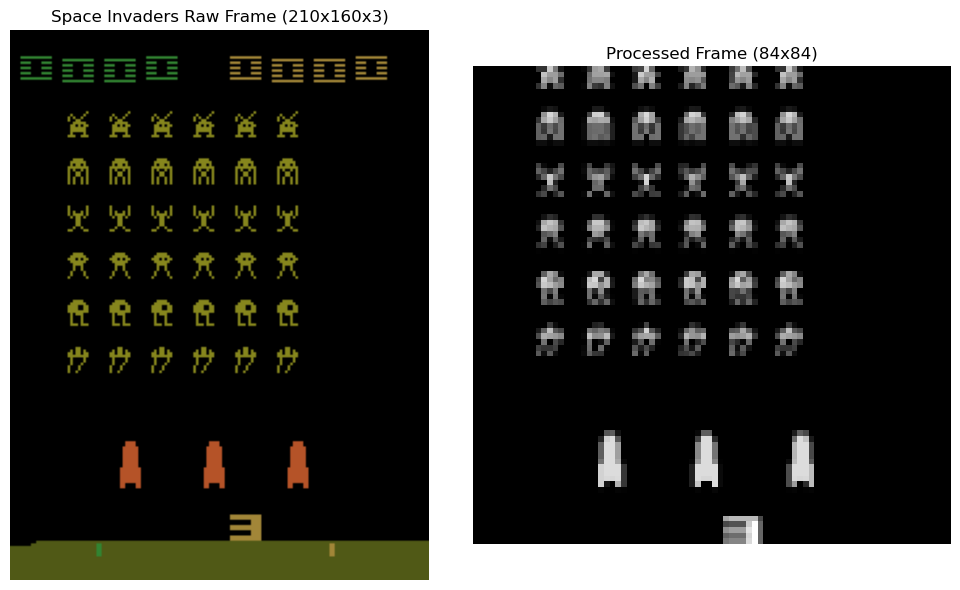

In [9]:
# Test the network
env = gym.make('SpaceInvadersNoFrameskip-v4')
state, _ = env.reset()

frame_stack = FrameStack(2)
stacked = frame_stack.reset(state)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_agent = PPOAgent(input_channels=2, action_size=env.action_space.n).to(device)

with torch.no_grad():
    state_tensor = torch.FloatTensor(stacked).unsqueeze(0).to(device)
    logits, value = test_agent(state_tensor)
    action, log_prob, _ = test_agent.get_action(state_tensor)
    
    # Test evaluate_actions
    new_log_prob, new_value, entropy = test_agent.evaluate_actions(state_tensor, action)
    
print(f"Input shape: {state_tensor.shape}")
print(f"Logits shape: {logits.shape}")
print(f"Value: {value.item():.4f}")
print(f"Action: {action.item()}")
print(f"Log prob: {log_prob.item():.4f}")
print(f"Entropy: {entropy.item():.4f}")
print(f"Action space size (Space Invaders): {env.action_space.n}")

total_params = sum(p.numel() for p in test_agent.parameters())
conv_params = sum(p.numel() for name, p in test_agent.named_parameters() if 'conv' in name)
actor_params = sum(p.numel() for name, p in test_agent.named_parameters() if 'actor' in name or 'policy' in name)
critic_params = sum(p.numel() for name, p in test_agent.named_parameters() if 'critic' in name or 'value' in name)

print(f"\nTotal parameters: {total_params:,}")
print(f"Shared CNN: {conv_params:,} ({conv_params/total_params*100:.1f}%)")
print(f"Actor: {actor_params:,} ({actor_params/total_params*100:.1f}%)")
print(f"Critic: {critic_params:,} ({critic_params/total_params*100:.1f}%)")

# Show a sample frame
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.imshow(state)
plt.title('Space Invaders Raw Frame (210x160x3)')
plt.axis('off')

plt.subplot(1, 2, 2)
processed = preprocess_frame(state)
plt.imshow(processed, cmap='gray')
plt.title('Processed Frame (84x84)')
plt.axis('off')
plt.tight_layout()
plt.show()

env.close()

## Test Rollout Buffer and GAE

In [10]:
# Test rollout buffer
test_buffer = RolloutBuffer()

# Add some dummy transitions
for i in range(10):
    test_buffer.add(
        state=np.random.randn(2, 84, 84),
        action=np.random.randint(0, 6),
        reward=np.random.randn(),
        done=(i == 9),
        value=np.random.randn(),
        log_prob=np.random.randn()
    )

print(f"Buffer size: {len(test_buffer)}")

# Test GAE computation
test_buffer.compute_gae(last_value=0.0, gamma=0.99, gae_lambda=0.95)

print(f"Advantages shape: {test_buffer.advantages.shape}")
print(f"Returns shape: {test_buffer.returns.shape}")
print(f"Sample advantages: {test_buffer.advantages[:3]}")
print(f"Sample returns: {test_buffer.returns[:3]}")

# Test batch generation
device = torch.device("cpu")
batch_count = 0
for batch in test_buffer.get_batches(batch_size=4, device=device):
    states, actions, old_log_probs, advantages, returns = batch
    batch_count += 1
    if batch_count == 1:
        print(f"\nFirst batch shapes:")
        print(f"  States: {states.shape}")
        print(f"  Actions: {actions.shape}")
        print(f"  Old log probs: {old_log_probs.shape}")
        print(f"  Advantages: {advantages.shape}")
        print(f"  Returns: {returns.shape}")

print(f"\nTotal batches: {batch_count}")

Buffer size: 10
Advantages shape: (10,)
Returns shape: (10,)
Sample advantages: [-1.01946647  1.04428406  0.14968311]
Sample returns: [0.71071588 0.66237915 0.28285156]

First batch shapes:
  States: torch.Size([4, 2, 84, 84])
  Actions: torch.Size([4])
  Old log probs: torch.Size([4])
  Advantages: torch.Size([4])
  Returns: torch.Size([4])

Total batches: 3


## Start Training

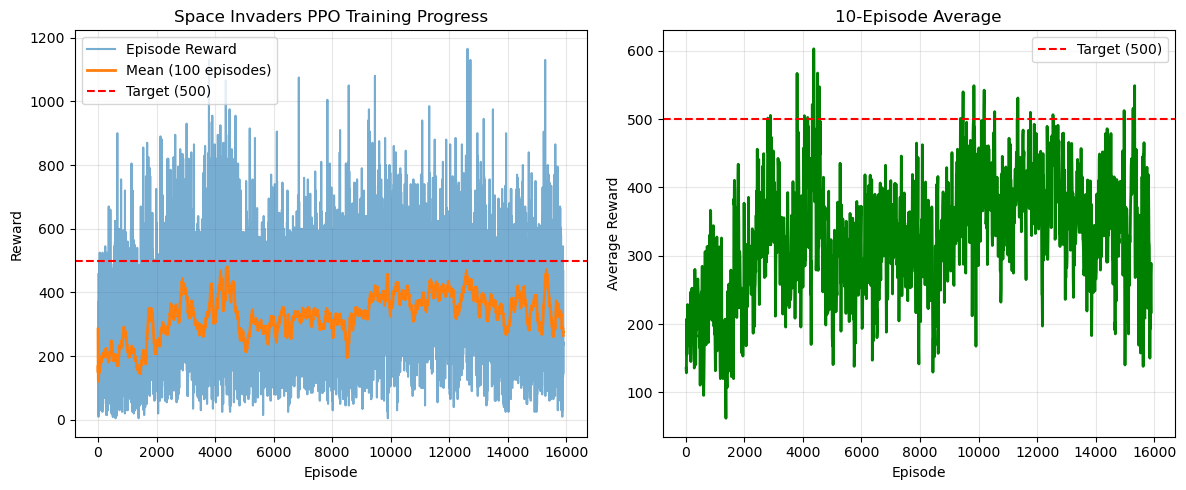

Episode 15900 | Reward:  310.0 | Avg(10): 229.50 | Mean(100): 265.90 | Max: 1165.0 | Steps: 9,991,319
Episode 15910 | Reward:  350.0 | Avg(10): 314.00 | Mean(100): 257.40 | Max: 1165.0 | Steps: 9,997,166


2026/02/05 08:16:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Max timesteps (10,000,000) reached.


2026/02/05 08:16:52 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0.dev20250930+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0.dev20250930' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/02/05 08:16:56 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0.dev20250930+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0.dev20250930' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/02/05 08:16:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Training completed!
Artifacts saved in: /home/bmartins/dev/rl_study/artifacts/run_ffc6cd06fa21476380e8f84472efd3db
Total updates: 1250000
Total timesteps: 10,000,000


final_episode,▁
final_mean_reward,▁
grad_norms/actor_fc.bias,▁▂▂▃▄▅▃▄▄▃▂▇▆▅▄▆▅▄▅▄▄▆▁▄▆█▃▄▁▃▂▆▄▄▇█▂▅▆▅
grad_norms/actor_fc.weight,▂▅▇▇▅▄▄▅▃▅▄▆▇▇█▆▆▄▄▅▇▆▆▄▅▂▂▃▃▆▁▄▇▅▃▂▁▄▃▄
grad_norms/conv.0.bias,▃▆▄▄▅▅▂▃▄▆▆▅▆▃▆▄▄▄▄▅▁▅▅▇▄▆▂▄▄▃▆▅▆▅▄█▅▃▄▆
grad_norms/conv.0.weight,▃▅▄▁▂▅▅▃▅▇▅▅▆▅▄▇▃▃▄▂▄▅▃▃▃▄▃▅█▂▆▆▆▂▁▇▇▁▄▄
grad_norms/conv.2.bias,▂▁▃▅▆▆▅▅▅▅▅▄▅▇▅▆▆▆▄▇█▆▇▄▆▇▇█▃▄▅▇▇▅▄▆▆▄▆▅
grad_norms/conv.2.weight,▆▃█▅▆▅▆▄▆█▅▆▇▇▆▅▇▇▅▄▅▆▅▅▅▃▂▂▃▃▆▅▅▅▄▅▄▇▄▁
grad_norms/conv.4.bias,▂▅▄▄▄▅▄▂▃▃▂▅▃▄▄▆▂▄▄▃▆▄▂▆▂▇▂▄▃▃▄▂▂▂▂▃▃█▂▁
grad_norms/conv.4.weight,▄▄▆▆▃█▆▃▃▅▆█▆▆▆▅▅▄▄▃▄▃▂▅▄▄▅▅▅▄▇▃▃▅█▂▂▃▁▃
grad_norms/critic_fc.bias,▁▂▂▂▄▂▂▁▂▂▁▂▂▂█▃▃▂▂▃▂▂▂▃▂▄▂▁▅▂▃▃▂▂▂▁▂▃▂▃



Training completed!


In [11]:
# Ensure no active MLflow runs
if mlflow.active_run():
    print("Ending active MLflow run...")
    mlflow.end_run()

# Train the agent
trained_agent, rewards = train_ppo()
print("\nTraining completed!")

## Final Results Plot

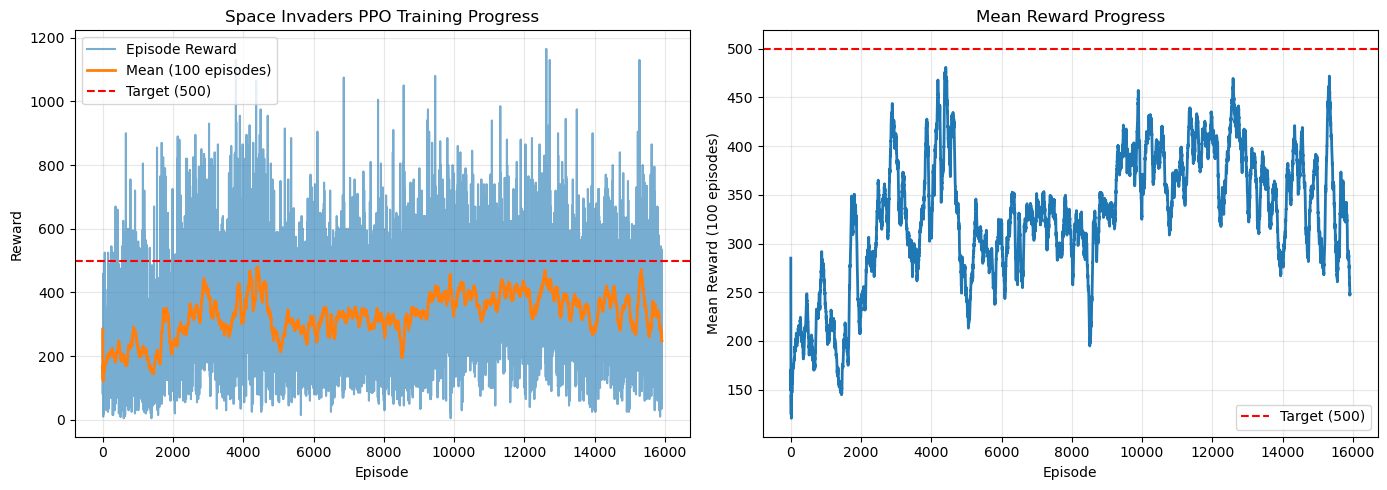

Final mean reward: 248.15
Max reward: 1165.00
Episodes trained: 15917


In [12]:
# Plot final results
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(rewards, alpha=0.6, label='Episode Reward')
if len(rewards) >= 100:
    moving_avg = [np.mean(rewards[max(0, i-99):i+1]) for i in range(len(rewards))]
    plt.plot(moving_avg, label='Mean (100 episodes)', linewidth=2)
plt.axhline(y=MEAN_REWARD_BOUND, color='r', linestyle='--', label=f'Target ({MEAN_REWARD_BOUND})')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Space Invaders PPO Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
if len(rewards) >= 100:
    moving_avg = [np.mean(rewards[max(0, i-99):i+1]) for i in range(len(rewards))]
    plt.plot(moving_avg, linewidth=2)
    plt.axhline(y=MEAN_REWARD_BOUND, color='r', linestyle='--', label=f'Target ({MEAN_REWARD_BOUND})')
plt.xlabel('Episode')
plt.ylabel('Mean Reward (100 episodes)')
plt.title('Mean Reward Progress')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final mean reward: {np.mean(rewards[-100:]):.2f}")
print(f"Max reward: {max(rewards):.2f}")
print(f"Episodes trained: {len(rewards)}")